# ED408 — Statistical Machine Learning II Lab
## Experiment 6: Outlier detection and treatment (z-score and IQR)
**Dataset:** Berkeley Segmentation Dataset (BSDS500) — boundary vs non-boundary pixel classification (17 local features; consensus human labels; train/test pixels from disjoint images).

*This notebook is standalone: it repeats the common data-loading step shared by all Module-I experiments. Requires `bsds_pixels.npz` (built by `extract_bsds.py`).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="deep")

D = np.load("bsds_pixels.npz", allow_pickle=True)
X_tr, y_tr = D["X_tr"].astype(float), D["y_tr"].astype(int)
X_te, y_te = D["X_te"].astype(float), D["y_te"].astype(int)
features = list(D["features"])

print("train:", X_tr.shape, " test:", X_te.shape)
print("boundary rate  train:", round(float(y_tr.mean()),4), " test:", round(float(y_te.mean()),4))
pd.DataFrame(X_tr, columns=features).describe().T.round(2)
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

train: (48000, 17)  test: (18000, 17)
boundary rate  train: 0.2667  test: 0.2667


## Data provenance (shared by all labs)

Pixels were sampled from **80 training images** and **30 test images** of BSDS500. Per image: up to 160 consensus-boundary pixels and 440 clear non-boundary pixels, with an 8-px border excluded to avoid filter edge artefacts. Feature extraction code: `extract_bsds.py` (included in the package; complete pipeline maintained on GitHub).

---
# Lab 6 — Outlier detection & treatment (z-score and IQR)

Filter responses are heavy-tailed, so the two rules disagree wildly — a key teaching point. We (a) quantify flagged fractions per feature per method, (b) show why the z-score is unreliable here (its mean/std are contaminated by the very outliers being tested — the *masking effect*), and (c) treat outliers by **winsorisation** and compare with a **robust z-score (median/MAD)** — judging treatment by downstream model AUC.

A subtlety specific to this dataset: extreme filter responses are **not measurement errors** — they are the strongest, most obvious boundaries in the image. Treating them as noise may therefore *hurt*.

% of rows flagged as outliers:
            z-score>3  robust-z>3.5  IQR 1.5x
L                0.00          0.00      0.00
a                1.93          4.17      7.78
gradmag_s1       2.44          8.77      7.66
abslap_s1        2.30         10.32      7.46


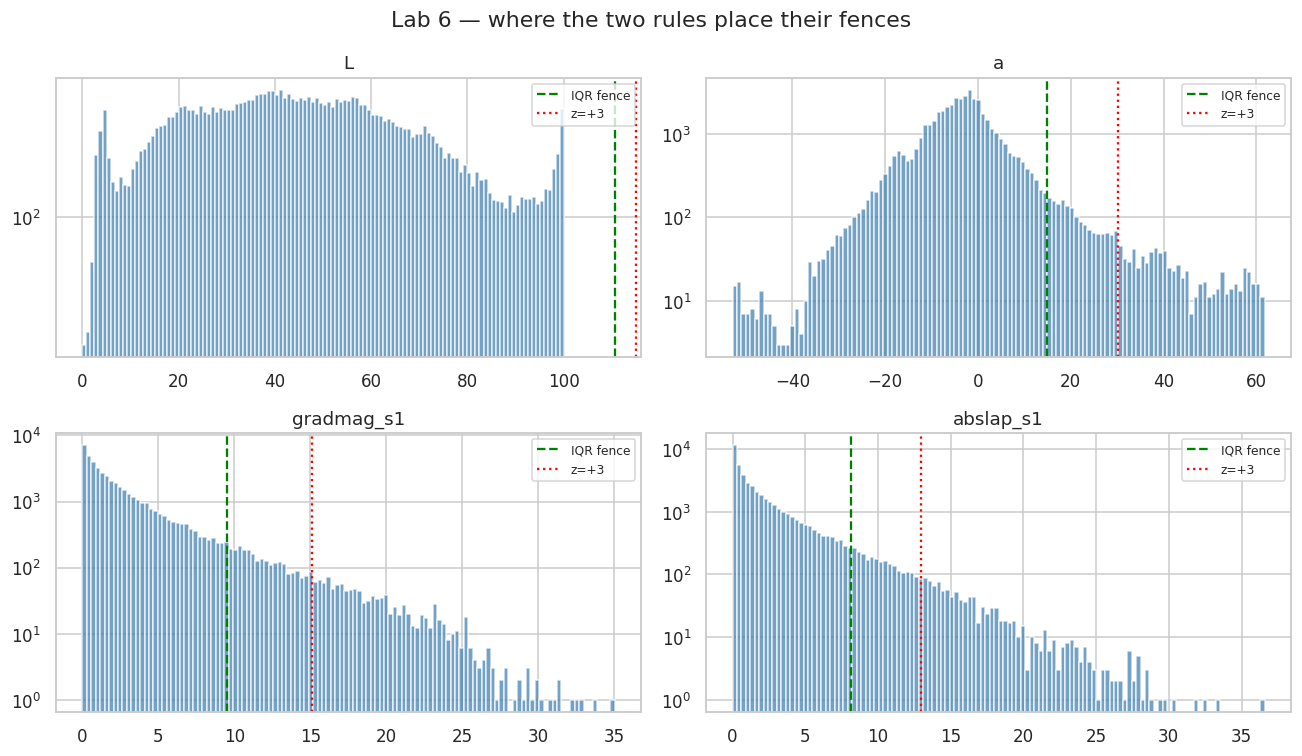

In [2]:
target_cols = ["L", "a", "gradmag_s1", "abslap_s1"]
Df = pd.DataFrame(X_tr, columns=features)[target_cols]

def zscore_mask(x, t=3.0):
    return np.abs((x - x.mean()) / x.std()) > t

def robust_z_mask(x, t=3.5):
    mad = np.median(np.abs(x - np.median(x))) + 1e-12
    return np.abs(0.6745 * (x - np.median(x)) / mad) > t

def iqr_mask(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75]); i = q3 - q1
    return (x < q1 - k*i) | (x > q3 + k*i)

summary = pd.DataFrame({c: {"z-score>3": zscore_mask(Df[c]).mean()*100,
                            "robust-z>3.5": robust_z_mask(Df[c]).mean()*100,
                            "IQR 1.5x": iqr_mask(Df[c]).mean()*100} for c in target_cols}).T
print("% of rows flagged as outliers:")
print(summary.round(2))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, c in zip(axes.ravel(), target_cols):
    x = Df[c]
    ax.hist(x, bins=120, color="steelblue", alpha=.75)
    q1, q3 = np.percentile(x, [25,75]); i = q3-q1
    ax.axvline(q3 + 1.5*i, c="green", ls="--", label="IQR fence")
    ax.axvline(x.mean() + 3*x.std(), c="red", ls=":", label="z=+3")
    ax.set_yscale("log"); ax.set_title(c); ax.legend(fontsize=8)
plt.suptitle("Lab 6 — where the two rules place their fences"); plt.tight_layout(); plt.show()

In [3]:
from sklearn.metrics import roc_auc_score

# scratch model from Lab 4, reused to judge outlier treatment downstream
class LogRegGD:
    def __init__(self, lr=0.1, n_iter=3000, l2=1e-3, class_weight=None):
        self.lr, self.n_iter, self.l2, self.class_weight = lr, n_iter, l2, class_weight

    @staticmethod
    def _sigmoid(z):
        out = np.empty_like(z)
        pos = z >= 0
        out[pos] = 1 / (1 + np.exp(-z[pos]))
        e = np.exp(z[~pos]); out[~pos] = e / (1 + e)
        return out

    def fit(self, X, y):
        n, m = X.shape
        self.w, self.b = np.zeros(m), 0.0
        w_i = np.ones(n)
        if self.class_weight == "balanced":
            w_i = np.where(y==1, n/(2*y.sum()), n/(2*(n-y.sum())))
        self.loss_ = []
        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            p = self._sigmoid(z)
            # stable log-loss: log(1+e^{-|z|}) + max(z,0) - z*y
            ll = (w_i * (np.log1p(np.exp(-np.abs(z))) + np.maximum(z,0) - z*y)).mean()
            self.loss_.append(ll + 0.5*self.l2*(self.w @ self.w)/n)
            g = w_i * (p - y)
            self.w -= self.lr * (X.T @ g / n + self.l2 * self.w / n)
            self.b -= self.lr * g.mean()
        return self

    def predict_proba(self, X): return self._sigmoid(X @ self.w + self.b)
    def predict(self, X, t=0.5): return (self.predict_proba(X) >= t).astype(int)

In [4]:
# treatment: winsorise the filter-response features at IQR fences from TRAIN only
heavy = [c for c in features if c.startswith(("gradmag","abslap","orient","st_","localstd"))]
X_wins, X_wins_te = X_tr.copy(), X_te.copy()
for c in heavy:
    j = features.index(c)
    lo, hi = np.percentile(X_tr[:, j], [25,75]); i = hi-lo
    X_wins[:, j]    = np.clip(X_tr[:, j], lo-1.5*i, hi+1.5*i)
    X_wins_te[:, j] = np.clip(X_te[:, j], lo-1.5*i, hi+1.5*i)   # fences from TRAIN only

for name, (A, B) in {"raw": (X_tr, X_te), "winsorised": (X_wins, X_wins_te)}.items():
    m, s = A.mean(0), A.std(0)+1e-12
    model = LogRegGD(class_weight="balanced").fit((A-m)/s, y_tr)
    print(f"{name:11s} logistic AUC = {roc_auc_score(y_te, model.predict_proba((B-m)/s)):.4f}")

raw         logistic AUC = 0.8362


winsorised  logistic AUC = 0.8362


**Observations.** The masking effect appears exactly as theory predicts: on heavy-tailed filter responses the classical z-score flags far fewer points than IQR because its own mean/std are inflated by the tail, while the robust median/MAD z-score tracks the IQR rule. On the near-symmetric L channel the rules roughly agree. The downstream comparison quantifies the domain-specific twist: here the "outliers" carry the strongest boundary signal, so aggressive clipping is not automatically beneficial — outlier treatment is an empirical decision, never a ritual.